In [8]:
import pandas as pd
import torch
import numpy as np

# Import các module tự viết
from src.config import seed_everything, DEVICE
from src.data_utils import feature_engineering, prepare_dataloaders
from src.models import LSTMModel, Seq2SeqModel
from src.train_utils import train_model, evaluate_task1, evaluate_task2

# Cố định random seed để kết quả không nhảy lung tung
seed_everything(42)
print(f"Run on: {DEVICE}")

Seed set to 42. Device: cuda
Run on: cuda


In [9]:
# 1. Load dữ liệu
# Đảm bảo bạn đã để file csv đúng chỗ: final_project/data/ETTh1.csv
df = pd.read_csv('data/ETTh1.csv')

# 2. Tạo đặc trưng (Feature Engineering)
data_fe = feature_engineering(df)

print("Dữ liệu gốc:", df.shape)
print("Dữ liệu sau khi Feature Engineering:", data_fe.shape)
print("Các features đầu vào:", data_fe.columns.tolist())

Dữ liệu gốc: (17420, 8)
Dữ liệu sau khi Feature Engineering: (17396, 20)
Các features đầu vào: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'Total_Load', 'Total_Load_Sq', 'OT_lag_1h', 'OT_lag_2h', 'OT_lag_3h', 'OT_lag_24h', 'OT_roll_mean_6h', 'OT_roll_std_6h', 'Load_roll_mean_3h', 'OT']


## **Task 1**


   BẮT ĐẦU TASK 1: DỰ BÁO ĐIỂM (t+2)
--- Bắt đầu Data Augmentation (Noise Level=0.01) ---
Kích thước gốc: (12177, 20)
-> Đã gộp dữ liệu. Kích thước mới: (24354, 20)
--- Starting Training: task1_best.pth (Teacher Forcing=False) ---
Epoch [5/100] | Train: 0.001506 | Val: 0.000920
Epoch [10/100] | Train: 0.001124 | Val: 0.000550
Epoch [15/100] | Train: 0.000887 | Val: 0.000471
Epoch [20/100] | Train: 0.000825 | Val: 0.000315
Epoch [25/100] | Train: 0.000790 | Val: 0.000320
Epoch [30/100] | Train: 0.000775 | Val: 0.000250
Epoch [35/100] | Train: 0.000758 | Val: 0.000345
Epoch [40/100] | Train: 0.000740 | Val: 0.000272
Epoch [45/100] | Train: 0.000729 | Val: 0.000364
Epoch [50/100] | Train: 0.000717 | Val: 0.000360
Epoch [55/100] | Train: 0.000707 | Val: 0.000280
Epoch [60/100] | Train: 0.000685 | Val: 0.000324
Epoch [65/100] | Train: 0.000681 | Val: 0.000435
Early stopping triggered!


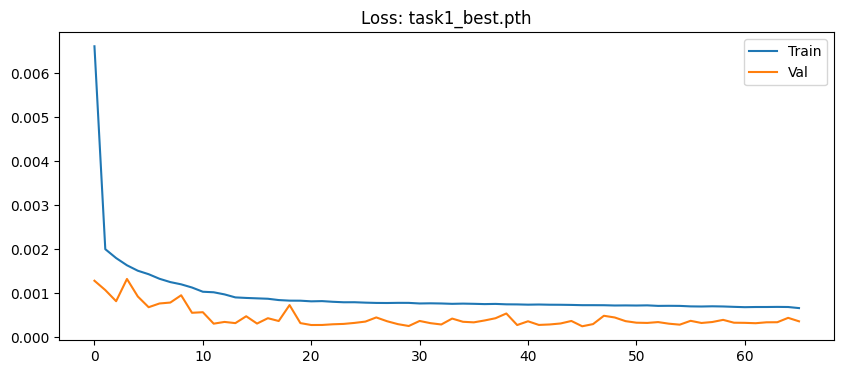

In [10]:
print("\n" + "="*40)
print("   BẮT ĐẦU TASK 1: DỰ BÁO ĐIỂM (t+2)")
print("="*40)

# --- CẤU HÌNH TASK 1 ---
SEQ_LEN = 24       # Nhìn lại 24 giờ
PRED_LEN = 1       # Dự báo 1 điểm
OFFSET = 1         # Cách hiện tại 1 bước (để ra t+2)
BATCH_SIZE = 64
AUGMENT = True
NOISE_LEVEL = 0.01

# 1. Chuẩn bị Dataloader
train_loader_t1, val_loader_t1, test_loader_t1, scaler_t1 = prepare_dataloaders(
    data_fe, SEQ_LEN, PRED_LEN, OFFSET, BATCH_SIZE, AUGMENT, NOISE_LEVEL
)

# 2. Khởi tạo Model LSTM
input_dim = data_fe.shape[1] # Số lượng features (khoảng 22)
model_t1 = LSTMModel(
    input_dim=input_dim, 
    hidden_dim=64, 
    layer_dim=2, 
    output_dim=1
).to(DEVICE)

# 3. Train Model
model_t1 = train_model(
    model_t1, 
    train_loader_t1, 
    val_loader_t1, 
    num_epochs=100, 
    patience=20, 
    model_name='task1_best.pth',
    use_teacher_forcing=False
)


--- KẾT QUẢ ĐÁNH GIÁ TASK 1 ---

=== TASK 1 RESULTS (t+2 Prediction) ===
NSE:  0.9052
R2:   0.9052
MAE:  0.6168 °C
RMSE: 0.8737 °C


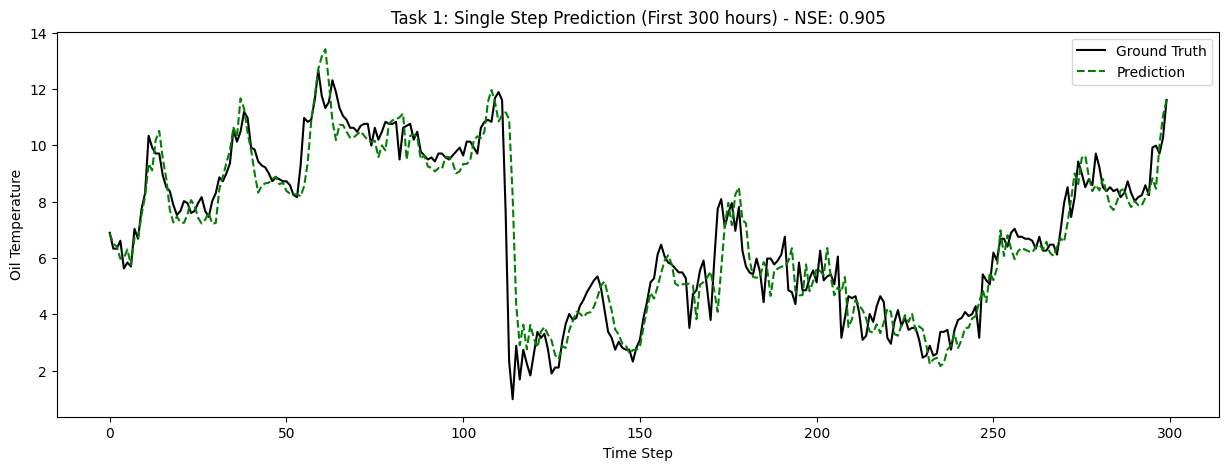

In [11]:
print("\n--- KẾT QUẢ ĐÁNH GIÁ TASK 1 ---")
evaluate_task1(model_t1, test_loader_t1, scaler_t1)

# **Task 2**


   BẮT ĐẦU TASK 2: DỰ BÁO CHUỖI (Seq2Seq 5 Steps)
--- Bắt đầu Data Augmentation (Noise Level=0.01) ---
Kích thước gốc: (12177, 20)
-> Đã gộp dữ liệu. Kích thước mới: (24354, 20)
--- Starting Training: task2_best.pth (Teacher Forcing=False) ---
Epoch [5/100] | Train: 0.001732 | Val: 0.000740
Epoch [10/100] | Train: 0.001233 | Val: 0.000517
Epoch [15/100] | Train: 0.001059 | Val: 0.000657
Epoch [20/100] | Train: 0.000975 | Val: 0.000473
Epoch [25/100] | Train: 0.000907 | Val: 0.000492
Epoch [30/100] | Train: 0.000882 | Val: 0.000600
Early stopping triggered!


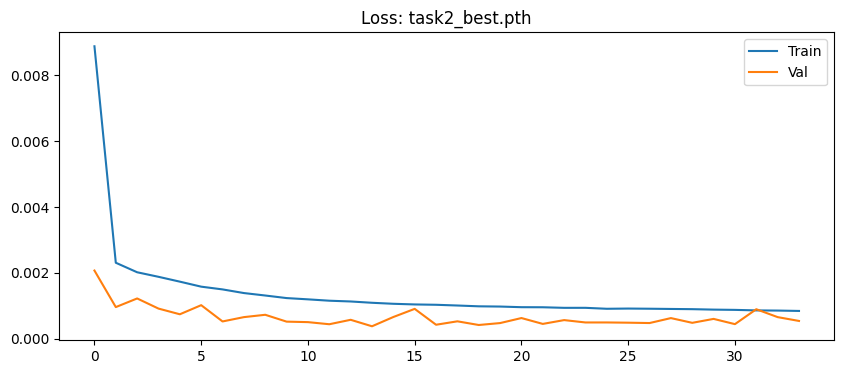

In [12]:
print("\n" + "="*40)
print("   BẮT ĐẦU TASK 2: DỰ BÁO CHUỖI (Seq2Seq 5 Steps)")
print("="*40)

# --- CẤU HÌNH TASK 2 ---
SEQ_LEN = 24       # Nhìn lại 24 giờ
PRED_LEN = 5       # Dự báo 5 bước liên tiếp
OFFSET = 0         # Ngay sau t (t+1 -> t+5)
BATCH_SIZE = 64
AUGMENT = True
NOISE_LEVEL = 0.01

# 1. Chuẩn bị Dataloader (Cần tạo lại vì y shape khác Task 1)
train_loader_t2, val_loader_t2, test_loader_t2, scaler_t2 = prepare_dataloaders(
    data_fe, SEQ_LEN, PRED_LEN, OFFSET, BATCH_SIZE, AUGMENT, NOISE_LEVEL
)

# 2. Khởi tạo Model Seq2Seq (Autoregressive)
input_dim = data_fe.shape[1]
model_t2 = Seq2SeqModel(
    input_dim=input_dim, 
    hidden_dim=64, 
    layer_dim=2,       # Dùng 1 layer cho nhẹ vì LSTMCell phức tạp
    output_seq_len=5,  # Horizon = 5
    output_dim=1       # Mỗi bước ra 1 giá trị (Nhiệt độ)
).to(DEVICE)

# 3. Train Model
model_t2 = train_model(
    model_t2, 
    train_loader_t2, 
    val_loader_t2, 
    num_epochs=100, 
    patience=20, 
    model_name='task2_best.pth',
    use_teacher_forcing=False
)


--- KẾT QUẢ ĐÁNH GIÁ TASK 2 ---

=== TASK 2 RESULTS (Seq2Seq 5-Steps) ===
Global NSE:  0.8690
Global MAE:  0.7329 °C
Global RMSE: 1.0273 °C

--- Step-wise Errors ---
Step t+1: MAE = 0.5581
Step t+2: MAE = 0.6418
Step t+3: MAE = 0.7251
Step t+4: MAE = 0.8188
Step t+5: MAE = 0.9206


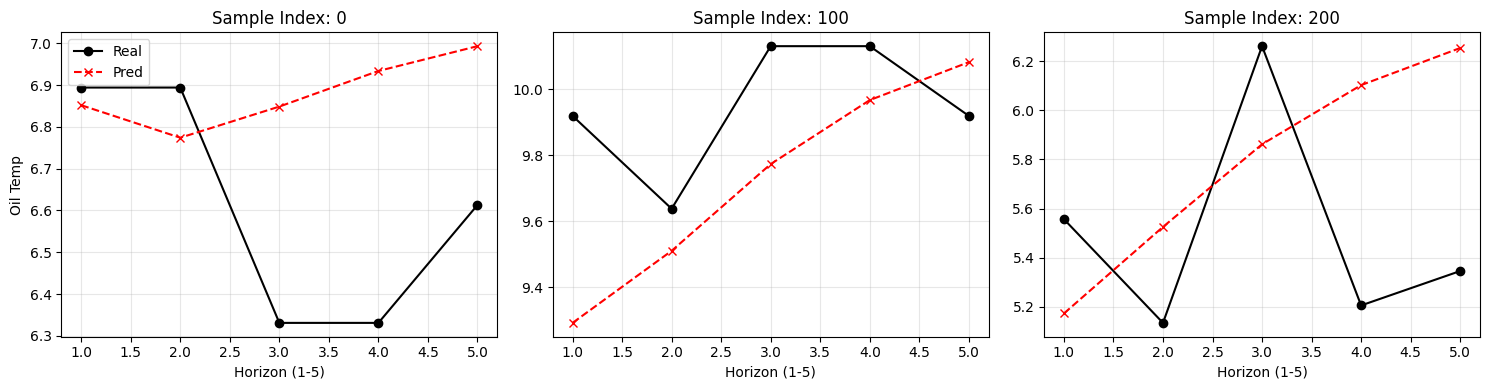

In [13]:
print("\n--- KẾT QUẢ ĐÁNH GIÁ TASK 2 ---")
evaluate_task2(model_t2, test_loader_t2, scaler_t2)

## **Task 2 + Attention**

--- Starting Training: task2_attn_best.pth (Teacher Forcing=False) ---
Epoch [5/100] | Train: 0.001609 | Val: 0.000876
Epoch [10/100] | Train: 0.001086 | Val: 0.000466
Epoch [15/100] | Train: 0.001019 | Val: 0.000827
Epoch [20/100] | Train: 0.000963 | Val: 0.000406
Epoch [25/100] | Train: 0.000902 | Val: 0.000562
Epoch [30/100] | Train: 0.000861 | Val: 0.000817
Epoch [35/100] | Train: 0.000813 | Val: 0.000648
Epoch [40/100] | Train: 0.000769 | Val: 0.000430
Early stopping triggered!


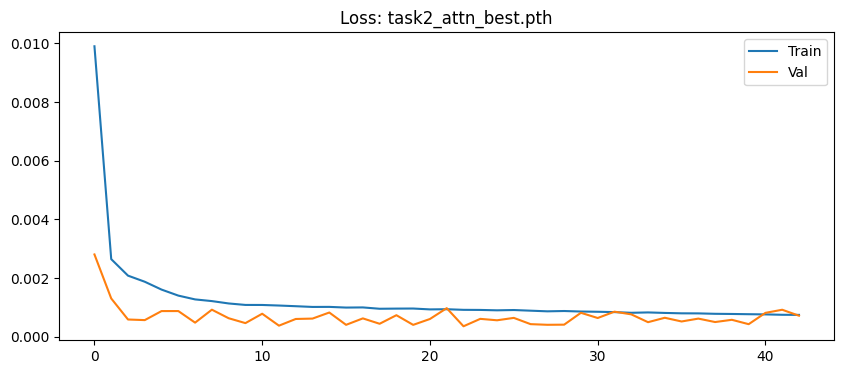

In [14]:
from src.models import Seq2SeqAttentionModel

# Khởi tạo model mới
model_attn = Seq2SeqAttentionModel(
    input_dim=data_fe.shape[1],
    hidden_dim=64, # Có thể tăng lên 128 nếu muốn mạnh hơn
    layer_dim=2,   # 2 layer LSTM cho Encoder
    output_seq_len=5,
    output_dim=1
).to(DEVICE)

# Train lại
model_attn = train_model(
    model_attn, 
    train_loader_t2, 
    val_loader_t2, 
    num_epochs=100, 
    patience=20, 
    model_name='task2_attn_best.pth',
    use_teacher_forcing=False
)


=== TASK 2 RESULTS (Seq2Seq 5-Steps) ===
Global NSE:  0.8177
Global MAE:  0.9584 °C
Global RMSE: 1.2118 °C

--- Step-wise Errors ---
Step t+1: MAE = 0.8094
Step t+2: MAE = 0.8996
Step t+3: MAE = 0.9533
Step t+4: MAE = 1.0338
Step t+5: MAE = 1.0957


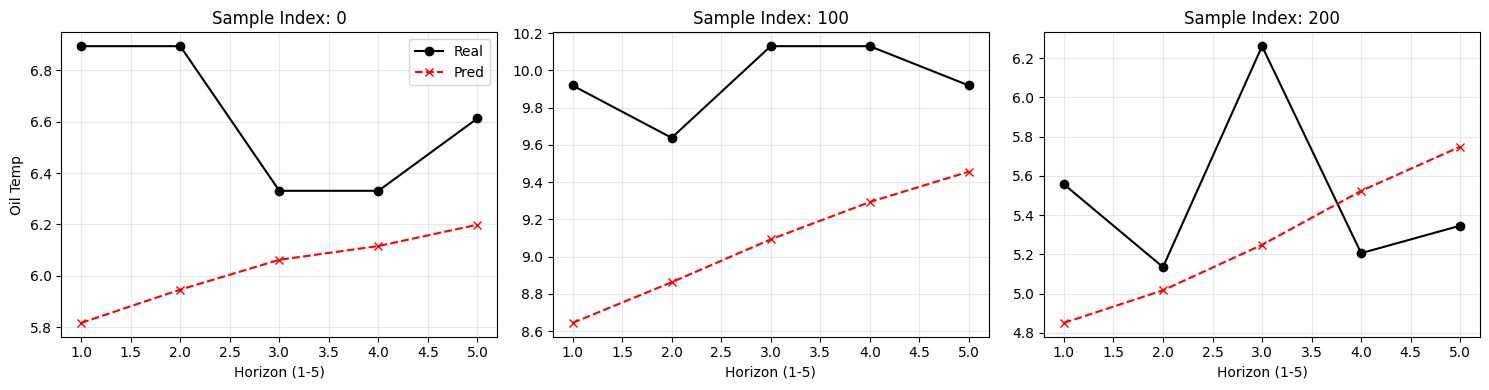

In [15]:
# Đánh giá
evaluate_task2(model_attn, test_loader_t2, scaler_t2)

## **Task 2 + Teacher Forcing**

--- Starting Training: task2_tf_best.pth (Teacher Forcing=True) ---
Epoch [5/100] | Train: 0.001857 | Val: 0.000798
Epoch [10/100] | Train: 0.001591 | Val: 0.000757
Epoch [15/100] | Train: 0.001234 | Val: 0.000729
Epoch [20/100] | Train: 0.001089 | Val: 0.000747
Epoch [25/100] | Train: 0.001017 | Val: 0.000549
Epoch [30/100] | Train: 0.000959 | Val: 0.000449
Epoch [35/100] | Train: 0.000934 | Val: 0.000583
Epoch [40/100] | Train: 0.000875 | Val: 0.000517
Epoch [45/100] | Train: 0.000832 | Val: 0.000492
Early stopping triggered!


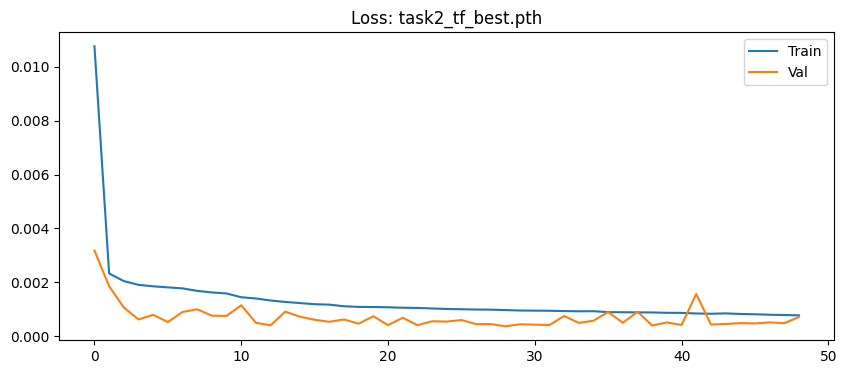

In [16]:
model_tf = Seq2SeqModel(
    input_dim=input_dim, 
    hidden_dim=64, 
    layer_dim=2,       # Attention phối hợp tốt nhất với 1 layer encoder
    output_seq_len=5, 
    output_dim=1
).to(DEVICE)

# --- BƯỚC 4: TRAIN (Tự động chạy Teacher Forcing Scheduler bên trong) ---
# Hàm train_model bạn vừa sửa sẽ tự động giảm teacher_forcing_ratio từ 0.5 về 0
model_tf = train_model(
    model_tf, 
    train_loader_t2, 
    val_loader_t2, 
    num_epochs=100, 
    patience=20,       # Tăng kiên nhẫn lên chút vì model phức tạp hơn
    model_name='task2_tf_best.pth',
    use_teacher_forcing=True
)


--- KẾT QUẢ CUỐI CÙNG (BEST CONFIGURATION) ---

=== TASK 2 RESULTS (Seq2Seq 5-Steps) ===
Global NSE:  0.8659
Global MAE:  0.7499 °C
Global RMSE: 1.0394 °C

--- Step-wise Errors ---
Step t+1: MAE = 0.5804
Step t+2: MAE = 0.6742
Step t+3: MAE = 0.7650
Step t+4: MAE = 0.8357
Step t+5: MAE = 0.8941


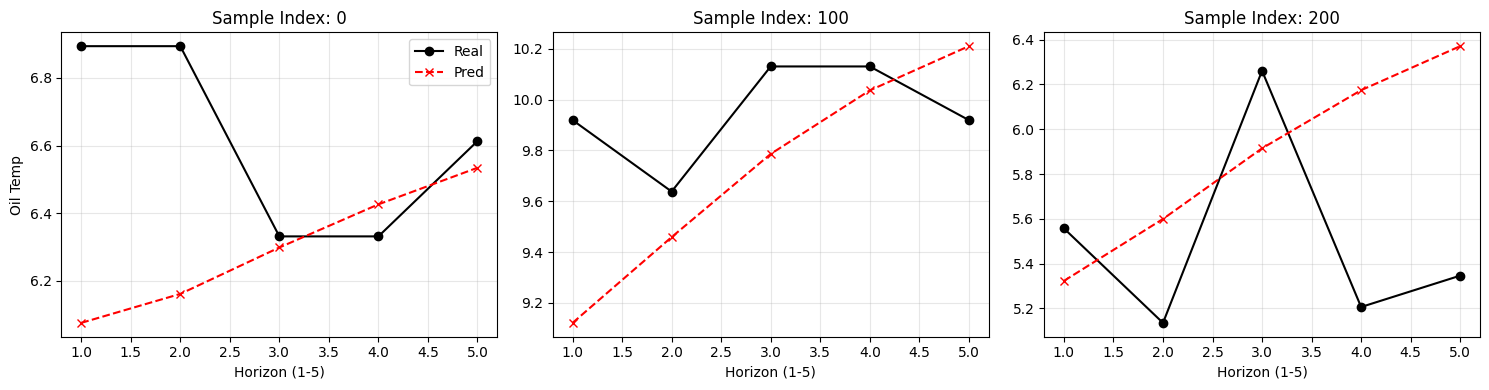

In [17]:
# --- BƯỚC 5: ĐÁNH GIÁ ---
print("\n--- KẾT QUẢ CUỐI CÙNG (BEST CONFIGURATION) ---")
evaluate_task2(model_tf, test_loader_t2, scaler_t2)

## **Task 2 Attention + Teacher Forcing**

--- Starting Training: task2_attn_tf_best.pth (Teacher Forcing=True) ---
Epoch [5/100] | Train: 0.001603 | Val: 0.000463
Epoch [10/100] | Train: 0.001424 | Val: 0.000487
Epoch [15/100] | Train: 0.001161 | Val: 0.000984
Epoch [20/100] | Train: 0.001050 | Val: 0.000593
Epoch [25/100] | Train: 0.000987 | Val: 0.000534
Epoch [30/100] | Train: 0.000934 | Val: 0.000568
Epoch [35/100] | Train: 0.000878 | Val: 0.000539
Epoch [40/100] | Train: 0.000813 | Val: 0.000723
Early stopping triggered!


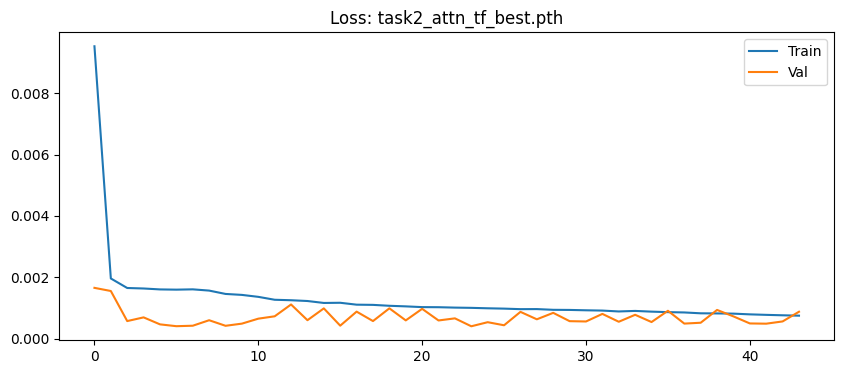

In [18]:
model_attn_tf = Seq2SeqAttentionModel(
    input_dim=data_fe.shape[1],
    hidden_dim=64, # Có thể tăng lên 128 nếu muốn mạnh hơn
    layer_dim=2,   # 2 layer LSTM cho Encoder
    output_seq_len=5,
    output_dim=1
).to(DEVICE)

# Train lại
model_attn_tf = train_model(
    model_attn_tf, 
    train_loader_t2, 
    val_loader_t2, 
    num_epochs=100, 
    patience=20, 
    model_name='task2_attn_tf_best.pth',
    use_teacher_forcing=True
)


=== TASK 2 RESULTS (Seq2Seq 5-Steps) ===
Global NSE:  0.8519
Global MAE:  0.8094 °C
Global RMSE: 1.0920 °C

--- Step-wise Errors ---
Step t+1: MAE = 0.6357
Step t+2: MAE = 0.7344
Step t+3: MAE = 0.8118
Step t+4: MAE = 0.8944
Step t+5: MAE = 0.9706


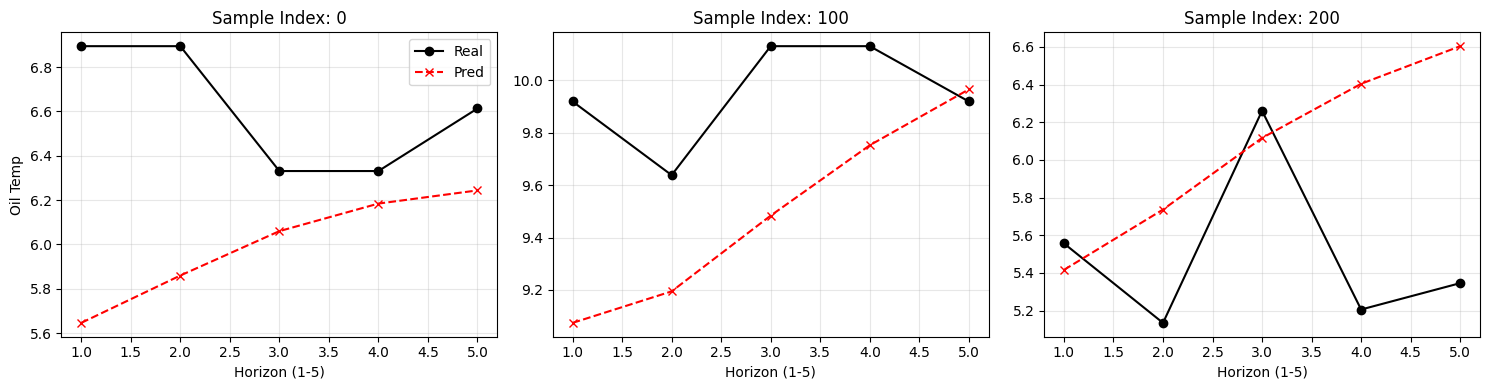

In [19]:
evaluate_task2(model_attn_tf, test_loader_t2, scaler_t2)